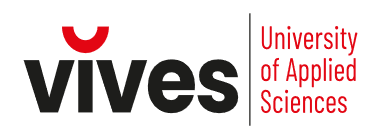<br>


**MACHINE LEARNING FUNDAMENTALS**<br>
APPLIED COMPUTER SCIENCE<br>
Specialization in Artificial Intelligence<br>
Andy Louwyck

---



---



# **K NEAREST NEIGHBORS: THEORY**

## 0. Introduction

K Nearest Neighbors (KNN) is a well-known and very easy machine learning algorithm that can be used for both **unsupervised and supervised learning**. In supervised learning, it is applicable to both **regression and classification tasks**. In this notebook, we will specifically focus on classification. So, KNN can be applied to solve the classification problems we discussed in the chapter on linear classification, with the difference that KNN is a **non-linear model** and thus much more sensitive to overfitting!

Since K Nearest Neighbors is a simple algorithm, you can find many blogs and videos on the internet that explain this algorithm; for example, this [blog](https://www.ibm.com/think/topics/knn) and [video](https://youtu.be/b6uHw7QW_n4?si=N4lLJnhyynlmxlaK) by IBM. This [video](https://youtu.be/0p0o5cmgLdE?si=Ik8HOVKsEWAQB9xp) explains the intuitive version of the algorithm that we will implement in this notebook.








## 1. Explanation

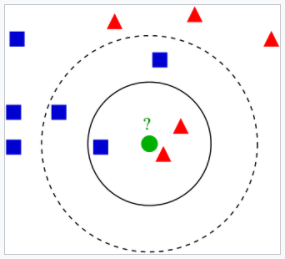

In the above figure, we see an example of binary classification with two classes: blue squares on the left and red triangles on the right, representing labeled training data. In the middle, there is a new data point, and the question is to which class this point belongs.

*Solution 1* involves taking the 3 closest points, which consist of 1 blue square and 2 red triangles, leading to the new data point being classified as a red triangle, corresponding to the majority of the given labels. If we take the 5 closest points, which include 3 blue squares and 2 red triangles, the new data point is classified as a blue square. The value of K, representing the number of closest points, is a hyperparameter. To determine the K closest points, we calculate the distance using methods such as Euclidean distance or Manhattan distance.

*Solution 2* involves drawing a circle with the new data point at its center and a given radius R, which is a hyperparameter. We then check the data points inside the circle. If the circle is drawn with a solid line, it contains 1 blue square and 2 red triangles, leading to the new point being classified as a red triangle. If the circle is drawn with a dotted line, it contains 3 blue squares and 2 red triangles, resulting in the new point being classified as a blue square.

In conclusion, the new label depends on the value of the number of neighbors K or the value of radius R, as well as the distance measure used, such as Euclidean or Manhattan distance. In this notebook, we will select the K closest points using Euclidean distance. But first, we explain how to calculate the Euclidean distance and the Manhattan distance between two points.

## 2. Euclidean vs Manhattan distance

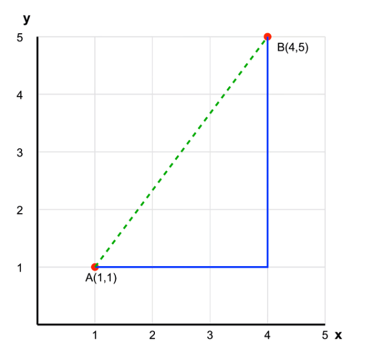

Consider the above axes representing two data points A and B with respective coordinates (1, 1) and (4, 5).

In [4]:
A = (1, 1)
B = (4, 5)

**Manhattan distance** $L_1$ between A and B equals the sum of the length of the two blue lines:

> $L_1 = |x_A - x_B| + |y_A - y_B|$

with $(x_A, y_A)$ and $(x_B, y_B)$ the coordinates of points A and B.

Let's calculate the Manhattan distance between points A and B depicted on the figure:

In [6]:
L1 = abs(A[0] - B[0]) + abs(A[1] - B[1])
L1

7

It's easy to see that the Manhattan distance is indeed equal to 3 + 4, which equals 7.

Manhattan distance is named after the grid-like street layout of Manhattan in New York City. It measures the distance between two points by summing the absolute differences of their coordinates, similar to how one would navigate city blocks in a grid pattern. This distance metric is also known as taxicab or city block distance.

**Euclidean distance** $L_2$ between A and B is the straight line distance or the distance [as the crow flies](https://en.wikipedia.org/wiki/As_the_crow_flies) between A and B. It is calculated by applying [Pythagoras' theorem](https://en.wikipedia.org/wiki/Pythagorean_theorem), which states that the square of the length of the hypotenuse of a right triangle equals the sum of the squares of the length of the legs of the right triangle. This implies that:

> $L_2 = \sqrt{\big(x_A-x_B \big)^2 + \big(y_A-y_B \big)^2}$

The above formula applied to data points A and B depicted on the above figure:

In [3]:
from math import sqrt

L2 = sqrt((A[0] - B[0])**2 + (A[1] - B[1])**2)
L2

5.0

The Euclidean distance indeed equals the square root of $3^2 + 4^2$, which is equal to the square root of 25, which is 5.

We use the symbols $L_1$ and $L_2$ here, because the Manhattan distance corresponds the the L1-norm and the Euclidean distance to the L2-norm. Actually, they are similar to the MAE and MSE we've discussed in the topic on linear regression.

Obviously, both the Manhattan and Euclidean distance can be generalized to more than two dimensions:

> $L_1 = \sum_{k=1}^N |x_{A,k} - x_{B,k}|$

and:

> $L_2 = \sqrt{\sum_{k=1}^N \big( x_{A,k} - x_{B,k} \big)^2}$

with $N$ the number of dimensions. So, in the above definitions, data points A and B have $N$ coordinates:

> $A = \big(x_{A,1}, x_{A,2}, ..., x_{A,N} \big)$
>
> $B = \big(x_{B,1}, x_{B,2}, ..., x_{B,N} \big)$

Using NumPy, it is very straightforward to implement these generalized expressions:

In [10]:
import numpy as np

manhattan = lambda A, B: np.sum(np.abs(np.array(A) - np.array(B)))
euclidean = lambda A, B: np.sqrt(np.sum((np.array(A) - np.array(B))**2))

In [12]:
print(f'L1 = {manhattan(A, B)}')
print(f'L2 = {euclidean(A, B)}')

L1 = 7
L2 = 5.0


Note that in one dimension, the Manhattan distance always equals the Euclidean distance:

> $L_1 = |x_A - x_B| = \sqrt{\big( x_A - x_B \big)^2} = L_2$

For example, consider points A and B on a one-dimensional axis with respective coordinates x=5 and x=10:

In [14]:
A = (5, )
B = (10, )

print(f'L1 = {manhattan(A, B)}')
print(f'L2 = {euclidean(A, B)}')

L1 = 5
L2 = 5.0


We get indeed the same result. In general, the Manhattan distance is always equal to or greater than the Euclidean distance.

As a final example, we generate two points A and B in a 6-dimensional space, and we calculate the Manhattan and Euclidean distance between those points:

In [72]:
np.random.seed(0)
N = 6
A = np.random.randint(0, 10, size=N)
B = np.random.randint(0, 10, size=N)

print(f'A = {A}')
print(f'B = {B}')
print()
print(f'L1 = {manhattan(A, B)}')
print(f'L2 = {euclidean(A, B)}')

A = [5 0 3 3 7 9]
B = [3 5 2 4 7 6]

L1 = 12
L2 = 6.324555320336759


## 3. Implementation of the KNN algorithm

In this section, we will implement an intuitive version of the KNN algorithm step by step, and we will test our implementation on the simple dataset of aliens that we encountered earlier in the topic on linear regression.

### Read dataset

Read data file `"aliens.csv"` into a Pandas DataFrame:

In [17]:
import pandas as pd

aliens = pd.read_csv("aliens.csv", sep=";")
aliens

,Sentence,Crack,Dunk,Mood
0,Crack!,1,0,sad
1,Dunk dunk!,0,2,sad
2,Crack dunk!,1,1,sad
3,Crack crack dunk!,2,1,sad
4,Crack dunk dunk dunk!,1,3,happy
5,Crack dunk dunk crack!,2,2,happy
6,Crack dunk crack dunk crack!,3,2,happy
7,Crack dunk dunk crack dunk!,2,3,happy


Create matrix `X` with the 2 features, i.e. number of times "Crack" and number of times "Dunk":

In [19]:
X = aliens[["Crack", "Dunk"]].to_numpy().astype(float)
X

array([[1., 0.],
       [0., 2.],
       [1., 1.],
       [2., 1.],
       [1., 3.],
       [2., 2.],
       [3., 2.],
       [2., 3.]])

Create vector `y` with the encoded labels, i.e. 1 if "happy", 0 if "sad":

In [20]:
y = (aliens.Mood == "happy").values.astype(int)
y

array([0, 0, 0, 0, 1, 1, 1, 1])

Make a scatter plot visualizing the dataset:

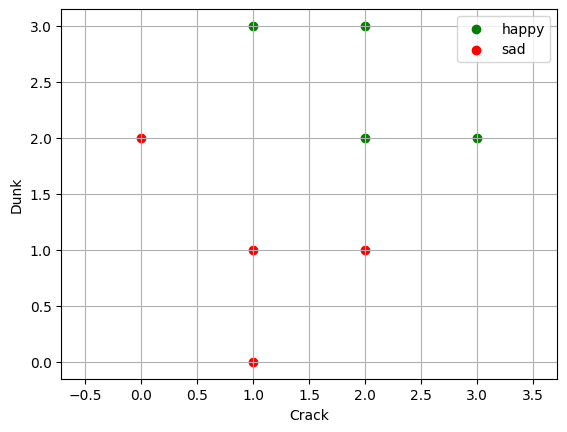

In [33]:
import matplotlib.pyplot as plt

def plot_aliens(X, y):
    plt.scatter(X[y==1, 0], X[y==1, 1], color='g', label='happy')
    plt.scatter(X[y==0, 0], X[y==0, 1], color='r', label='sad')
    plt.xlabel("Crack")
    plt.ylabel("Dunk")
    plt.legend(['happy', 'sad'])
    plt.grid();
    plt.axis('equal')

plot_aliens(X, y)

### Calculate Euclidean distances

We already discussed the Euclidean distance in the previous section, but now, we have to apply it to samples from a dataset:

Mathematical:
- $n$ samples or data points
- $m$ features $X_k$ = $X_1$, $X_2$, ..., $X_m$
- distance $d_{ij}$ between 2 data points $i$ and $j$

  = **Euclidean distance** in $m$ dimensions:
  > $d_{ij} = \sqrt{\sum_{k=1}^{m}{(X_{ik} - X_{jk})^2}}$

NumPy code:
- `n` samples = `n` rows in matrix `X`
- `m` features `X1`, `X2`, ..., `Xm` = `m` vectors = `m` columns in matrix `X`
- distance `d` between 2 data points (= 2 rows) `i` and `j`:
  > `d = sqrt(sum((X[i, :] - X[j, :])**2))`
- All data points: matrix `D` with `D[i, j] = d`

In case of KNN, we need to calculate the Euclidean distance between a (new) data point `x` and a sample from the training dataset `X`:

> `d = sqrt(sum((X - x)**2))`

As an example, consider a new alien who doesn't speak and defines a new data point `x = [0, 0]`. First, we calculate the differences:

In [25]:
x = np.array([0, 0])
X - x

array([[1., 0.],
       [0., 2.],
       [1., 1.],
       [2., 1.],
       [1., 3.],
       [2., 2.],
       [3., 2.],
       [2., 3.]])

Note how NumPy applies broadcasting: `x` is subtracted from each row of matrix `X`!

Calculating the square of the differences:

In [26]:
np.square(X - x) # (X - x)**2

array([[1., 0.],
       [0., 4.],
       [1., 1.],
       [4., 1.],
       [1., 9.],
       [4., 4.],
       [9., 4.],
       [4., 9.]])

Taking the sum of the squares of the differences:

In [27]:
np.sum(np.square(X - x), axis=1)

array([ 1.,  4.,  2.,  5., 10.,  8., 13., 13.])

Don't forget `axis=1`, because we work per row!

Finally, the full vectorized expression to calculate the Euclidean distance between a new data point `x` and the samples from dataset `X` is:

In [28]:
np.sqrt(np.sum(np.square(X - x), axis=1))

array([1.        , 2.        , 1.41421356, 2.23606798, 3.16227766,
       2.82842712, 3.60555128, 3.60555128])

Of course, it is better to make it a function:

In [29]:
distance = lambda X, x: np.sqrt(np.sum(np.square(X - x), axis=1))

Testing:

In [30]:
d = distance(X, np.array([0, 0]))
d

array([1.        , 2.        , 1.41421356, 2.23606798, 3.16227766,
       2.82842712, 3.60555128, 3.60555128])

We indeed get the same result.

Let's add the new point to the plot to verify the result:

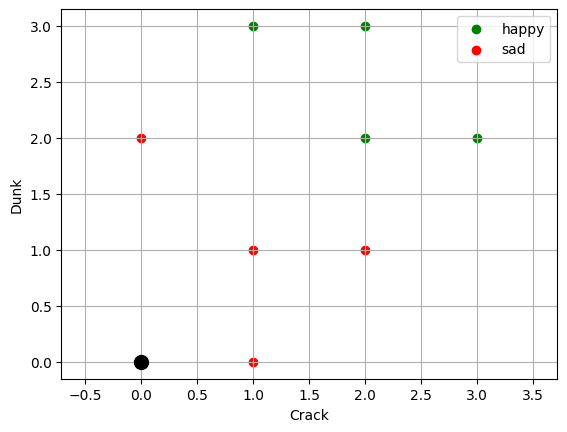

In [34]:
plot_aliens(X, y)
plt.plot(x[0], x[1], 'ko', markersize=10);

### Get K closest data points

To find the K closest points, we simply sort the calculated distances from smallest to largest. As we need the indices of the sorted samples, we will use NumPy's `argsort()` function!

In [38]:
sorted_indices = np.argsort(d)
sorted_indices

array([0, 2, 1, 3, 5, 4, 6, 7])

Actually, we only need the first `k` indices:

In [39]:
k = 3
sorted_indices[:k]

array([0, 2, 1])

In this way, we get the labels of the `k` closest data points:

In [40]:
k_labels = y[sorted_indices[:k]]
k_labels

array([0, 0, 0])

### Predict the labels

To predict the label or target of the new data point, we need to distinguish between regression and classification tasks:
- in regression: we calculate the (weighted) average of the labels of the K closest points
- in classification: we take the mode of the labels of the K closest points

In statistics, the **mode** is simply the most common element.

Using NumPy, we can apply function `unique()` to determine the most common label. Let's define a function `mode` so we can reuse the code:

In [42]:
def mode(data):
    values, counts = np.unique(data, return_counts=True)
    mode_index = np.argmax(counts)
    return values[mode_index]

data = np.array([1, 2, 2, 3, 4, 4, 4, 5])
print("Mode:", mode(data))

Mode: 4


Applied to the labels of the `k` nearest neighbors:

In [43]:
mode(k_labels)  # predicted label of new data point [0, 0]

np.int64(0)

Alternatively, we can use function `mode()` from the `scipy.stats` module:

In [44]:
from scipy.stats import mode

mode(data)

ModeResult(mode=np.int64(4), count=np.int64(3))

`ModeResult` returns two elements:
- the first element is the mode
- second element is the number of times the mode occurs

So, to get the mode, we do the following:

In [46]:
mode(data)[0]

np.int64(4)

Applied to predict the label of the new data point:

In [48]:
yp = mode(k_labels)[0]  # predicted label of new data point [0, 0]
yp

np.int64(0)

### Function `knn_classifier`

We refactor the code from the previous steps into a function `knn_classifier()`:

In [61]:
def knn_classifier(Xnew, X, y, k=3, distance=None):
    '''
    Intuitive implementation of the KNN algorithm for classification

    Xnew is a numpy array with p rows (= examples) and m columns (= features)
    X and y is the training dataset:
      X is a numpy array with n rows (= examples) and m columns (= features)
      y is a numpy array with n elements (= labels)
    k is the number of nearest neighbors (default is 3)
    distance is a function to calculate distances between points
      distance(X, x) is called where x is a new data point with m elements (= features)
      distance(X, x) returns vector d with n distances
      by default Euclidean distance is calculated
    return value: numpy array yp with p predicted labels for dataset Xnew
    '''
    if distance is None:
        distance = lambda X, x: np.sqrt(np.sum(np.square(X - x), axis=1))
    yp = []
    for x in Xnew:
        d = distance(X, x)
        sorted_indices = np.argsort(distance(X, x))
        k_labels = y[sorted_indices[:k]]
        yp.append(mode(k_labels)[0])
    return np.array(yp)

Testing with the training dataset:

In [62]:
yp = knn_classifier(Xnew=X, X=X, y=y)
yp

array([0, 0, 0, 0, 1, 1, 1, 1])

The predicted labels perfectly match the actual labels and we get an accuracy of 100%:

In [64]:
print(f'acc = {(yp == y).sum() / len(y)}')  # accuracy

acc = 1.0


Testing with points `x1 = [0, 0]` and `x2 = [3, 3]`

In [52]:
Xnew = np.array([[0, 0], [3, 3]])
knn_classifier(Xnew, X, y, k=3)

array([0, 1])

Let's visualize the new data points to verify the result:

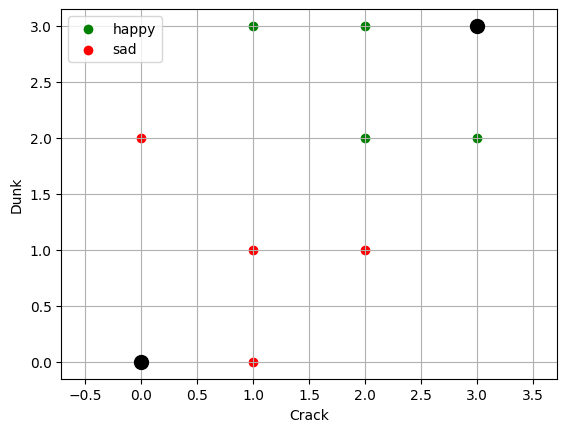

In [53]:
plot_aliens(X, y)
plt.plot(Xnew[:, 0], Xnew[:, 1], 'ko', markersize=10);

The predicted labels are correct:
- The first point (0, 0) should be "sad" (red) because the alien doesn't speak.
- The second point (3, 3) should be "happy" (green) because the alien says a lot.

## 4. Scikit-Learn

[Scikit-Learn](https://scikit-learn.org/stable/modules/neighbors.html) provides several K Nearest Neighbors algorithms for both supervised and unsupervised learning.

We look at the KNN classifier:

In [54]:
from sklearn.neighbors import KNeighborsClassifier as KNN

`KNeighborsClassifier` is a class with the same interface as `Perceptron`, `LogisticRegression`, and other classes.

The class constructor has the following input arguments:
- hyperparameter `n_neighbors`: number of nearest points K
- hyperparameter `metric`:
  - determines how the distance is calculated
  - if equal to `"minkowski"` with parameter `p=2`: Euclidean distance
- `algorithm`: there are different algorithms implemented.
- See [documentation](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html) for more information.

Applying the class to our example:

In [66]:
# instantiating class
knn = KNN(n_neighbors=3) # n_neighbors = K

In [67]:
# calling fit method
knn.fit(X, y)

KNeighborsClassifier(n_neighbors=3)

In [68]:
print(f'acc = {knn.score(X, y)}')  # accuracy

acc = 1.0


In [69]:
# predicting the labels of the training samples
knn.predict(X)

array([0, 0, 0, 0, 1, 1, 1, 1])

In [70]:
# predicting the labels of the new data points
knn.predict(Xnew)

array([0, 1])

As expected, we get the same result.

In Scikit-Learn, we invoke the `fit()` method, but actually, the KNN model is not trained like most other machine learning models. The model has no parameters and the labels of new data points are predicted on the fly. So the `fit()` method only stores the dataset. This is called **lazy learning**, as opposed to the **eager learning** of the models we've discussed in the previous topics.

## 5. Find the optimal K value

The choice of K value may have a significant impact on the model's tendency to underfit or overfit. Low K values can lead to **overfitting**, where the model is too sensitive to the noise in the training data and fails to generalize well to new data. On the other hand, high K values can result in **underfitting**, where the model is too generalized and fails to capture the underlying patterns in the data. Finding the right balance is key to achieving optimal model performance.

To determine the best value for K in K-Nearest Neighbors, it is essential to test a range of K values. Using a **validation** set or applying cross-validation helps to find the optimal value for K by evaluating the model's performance on different subsets of the data. Creating a plot of error versus K can visually demonstrate how the error rate changes with different K values, aiding in the selection of the most suitable K. This is similar to the model complexity graph we used to find the optimal degree with polynomial regression.

When dealing with (binary) classification, it is advisable to use **odd values** for K to avoid ties, ensuring a clear decision for each new data point. Additionally, considering domain-specific insights can provide valuable guidance in choosing an appropriate K value that aligns with the characteristics of the data and the problem at hand. It is also important to note that large K values can be computationally expensive, as they require more calculations to determine the nearest neighbors.



---

---
## Sources
* https://en.wikipedia.org/wiki/K-nearest_neighbors_algorithm
* https://scikit-learn.org/stable/modules/neighbors.html

---